In [9]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
import torchmetrics

In [10]:
train_data = pd.read_csv('data/train.csv')
train_data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
y = train_data['label'].values
X = train_data.drop('label',axis=1).values/255
X.shape,y.shape

((42000, 784), (42000,))

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=7)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((33600, 784), (8400, 784), (33600,), (8400,))

In [13]:
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

In [14]:
train = torch.utils.data.TensorDataset(X_train,y_train)
test = torch.utils.data.TensorDataset(X_test,y_test)

train_dataloader = torch.utils.data.DataLoader(train,batch_size = 32,shuffle = True)
test_dataloader = torch.utils.data.DataLoader(test, batch_size = 32, shuffle = False)

In [52]:
class Model9(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = torch.nn.Flatten()
        self.layer_2 = torch.nn.Linear(784,50)
        self.layer_3 = torch.nn.Linear(50,10) 
        self.layer_4 = torch.nn.Linear(10,10)
        self.relu_layer = torch.nn.ReLU()
    def forward(self,x):
        x = self.layer_1(x)
        x = self.relu_layer(self.layer_2(x))
        x = self.relu_layer(self.layer_3(x))
        x = self.layer_4(x)
        return x
    
basic_model = Model9()
basic_model

Model9(
  (layer_1): Flatten(start_dim=1, end_dim=-1)
  (layer_2): Linear(in_features=784, out_features=50, bias=True)
  (layer_3): Linear(in_features=50, out_features=10, bias=True)
  (layer_4): Linear(in_features=10, out_features=10, bias=True)
  (relu_layer): ReLU()
)

In [53]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [54]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = basic_model.parameters(),lr=0.001)
accuracy_fn = torchmetrics.Accuracy(task='multiclass',num_classes=10)

In [55]:
torch.manual_seed(7)
basic_model = basic_model.to(device)
history_logs = {'epoch':[],
                'train_loss':[],
                'train_accuracy':[],
                'test_loss':[],
                'test_accuracy':[]}
for epoch in range(10):
    print(f'Epoch : {epoch}\n---------')
    train_loss_full = 0
    train_accuracy_full = 0
    for batch,(X,y) in enumerate(train_dataloader):
        X,y = X.to(device).float(),y.to(device)
        basic_model.train()
        train_preds = basic_model(X)
        train_loss = loss_fn(train_preds,y)
        train_loss_full+=train_loss.item()
        train_accuracy = accuracy_fn(y,train_preds.argmax(dim=1)).item()
        train_accuracy_full+=train_accuracy
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
    train_loss_full/=len(train_dataloader)
    train_accuracy_full/=len(train_dataloader)
    basic_model.eval()
    with torch.inference_mode():
        test_loss_full = 0
        test_accuracy_full = 0
        for X,y in test_dataloader:
            X,y = X.to(device).float(),y.to(device)
            test_preds = basic_model(X)
            test_loss = loss_fn(test_preds,y)
            test_loss_full += test_loss
            test_accuracy = accuracy_fn(y, test_preds.argmax(dim=1)).item()
            test_accuracy_full += test_accuracy
        test_accuracy_full /= len(test_dataloader)
        test_loss_full /= len(test_dataloader)
    history_logs['epoch'].append(epoch)
    history_logs['train_loss'].append(train_loss_full)
    history_logs['train_accuracy'].append(train_accuracy_full)
    history_logs['test_loss'].append(test_loss_full.item())
    history_logs['test_accuracy'].append(test_accuracy_full)
    print(f'Train loss : {train_loss_full}| Train accuracy: {train_accuracy_full} | Test loss : {test_loss_full} | Test acc : {test_accuracy_full}')

Epoch : 0
---------
Train loss : 0.5921976653876759| Train accuracy: 0.825595238095238 | Test loss : 0.3108610212802887 | Test acc : 0.9102899239543726
Epoch : 1
---------
Train loss : 0.2579839647206522| Train accuracy: 0.9269345238095238 | Test loss : 0.22948817908763885 | Test acc : 0.93393536121673
Epoch : 2
---------
Train loss : 0.19504832561615676| Train accuracy: 0.9437797619047619 | Test loss : 0.20375514030456543 | Test acc : 0.9402328897338403
Epoch : 3
---------
Train loss : 0.15974393783314597| Train accuracy: 0.9530357142857143 | Test loss : 0.16973496973514557 | Test acc : 0.9508079847908745
Epoch : 4
---------
Train loss : 0.13532070555413764| Train accuracy: 0.9599107142857143 | Test loss : 0.16410067677497864 | Test acc : 0.9518773764258555
Epoch : 5
---------
Train loss : 0.11832356897138414| Train accuracy: 0.9654166666666667 | Test loss : 0.1631426215171814 | Test acc : 0.9493821292775665
Epoch : 6
---------
Train loss : 0.1035384255519048| Train accuracy: 0.969761

In [56]:
history_logs_df = pd.DataFrame(history_logs)
history_logs_df.set_index('epoch',inplace=True)
history_logs_df

,train_loss,train_accuracy,test_loss,test_accuracy
epoch,,,,
0,0.592198,0.825595,0.310861,0.910290
1,0.257984,0.926935,0.229488,0.933935
2,0.195048,0.943780,0.203755,0.940233
3,0.159744,0.953036,0.169735,0.950808
4,0.135321,0.959911,0.164101,0.951877
5,0.118324,0.965417,0.163143,0.949382
6,0.103538,0.969762,0.162563,0.953541
7,0.090017,0.973065,0.153520,0.955798
8,0.081161,0.975179,0.150084,0.958650


<Axes: xlabel='epoch'>

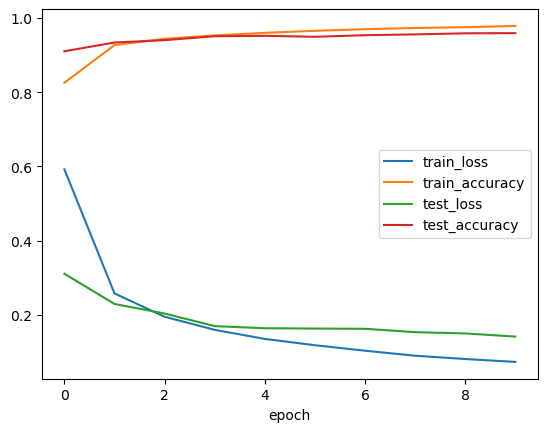

In [57]:
history_logs_df.plot()

In [66]:
test_data = pd.read_csv('data/test.csv')
test_data

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
torch.from_numpy(test_data.values)

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [68]:
test_data = torch.utils.data.TensorDataset(torch.from_numpy(test_data.values))
test_data = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)
test_data

In [70]:
basic_model.eval()
full_test_preds = []
with torch.inference_mode():
    for batch in test_data:
        X = batch[0].to(device).float()
        test_preds = basic_model(X)
        full_test_preds.append(test_preds.argmax(dim=1))
full_test_preds

[tensor([2, 0, 9, 9, 3, 7, 0, 3, 0, 3, 5, 7, 4, 0, 4, 3, 3, 1, 9, 0, 9, 1, 1, 5,
         7, 4, 2, 7, 4, 7, 7, 5]),
 tensor([4, 2, 6, 2, 5, 5, 1, 6, 7, 7, 4, 9, 8, 7, 8, 2, 6, 7, 6, 8, 8, 3, 8, 2,
         1, 2, 2, 0, 4, 1, 7, 0]),
 tensor([0, 0, 1, 9, 0, 1, 6, 5, 8, 8, 2, 8, 3, 9, 2, 3, 5, 4, 1, 0, 9, 2, 4, 3,
         6, 7, 2, 0, 6, 6, 1, 4]),
 tensor([3, 9, 7, 4, 0, 8, 2, 0, 7, 3, 0, 5, 0, 3, 0, 0, 4, 7, 1, 7, 1, 1, 5, 3,
         3, 7, 2, 8, 6, 3, 8, 7]),
 tensor([8, 4, 3, 5, 6, 0, 0, 0, 3, 1, 5, 0, 4, 3, 4, 5, 5, 8, 7, 7, 2, 8, 4, 3,
         5, 6, 5, 3, 7, 3, 7, 8]),
 tensor([3, 0, 4, 5, 1, 3, 7, 6, 3, 0, 2, 7, 8, 6, 1, 3, 7, 4, 1, 2, 4, 7, 5, 2,
         4, 9, 2, 1, 6, 0, 6, 1]),
 tensor([4, 9, 6, 0, 9, 7, 6, 9, 1, 9, 0, 9, 9, 0, 8, 4, 6, 2, 0, 9, 3, 6, 3, 2,
         1, 6, 3, 4, 2, 3, 1, 2]),
 tensor([2, 0, 4, 6, 1, 0, 0, 4, 9, 1, 7, 3, 2, 3, 8, 6, 8, 6, 2, 8, 5, 5, 4, 8,
         3, 8, 9, 7, 1, 3, 8, 4]),
 tensor([5, 1, 4, 5, 6, 3, 3, 5, 7, 0, 6, 8, 3, 1, 6, 0, 6, 3, 9, 9, 1, 

In [71]:
predictions = torch.cat(full_test_preds,dim=0)
predictions

tensor([2, 0, 9,  ..., 3, 9, 2])

In [ ]:
submission = pd.DataFrame({'ImageId':range(1,len(predictions)+1),
                           'Label':predictions.numpy()})
submission.set_index('ImageId',drop=True)
submission

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [82]:
submission.to_csv('submission.csv',index=False)